# Baseline Model - Linear Regression

## Objective

To build a baseline regression model using Linear Regression for predicting Remaining Useful Life (RUL). The model's performance will serve as a benchmark for evaluating more advanced machine learning algorithms.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
column_names = [
    "unit_number",
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for i in range(1,22):
    column_names.append(f"sensor_{i}")

train_df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

In [3]:
max_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()

train_df = train_df.merge(
    max_cycles.rename("max_cycle"),
    on="unit_number"
)

train_df["RUL"] = (
    train_df["max_cycle"] -
    train_df["time_in_cycles"]
)

train_df.drop(columns=["max_cycle"], inplace=True)

In [4]:
X = train_df.drop(
    columns=[
        "unit_number",
        "RUL"
    ]
)

y = train_df["RUL"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [7]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = lr_model.predict(
    X_test_scaled
)

In [9]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Linear Regression Results")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Results
-----------------------------------
MAE  : 30.54
RMSE : 39.70
R²   : 0.6550


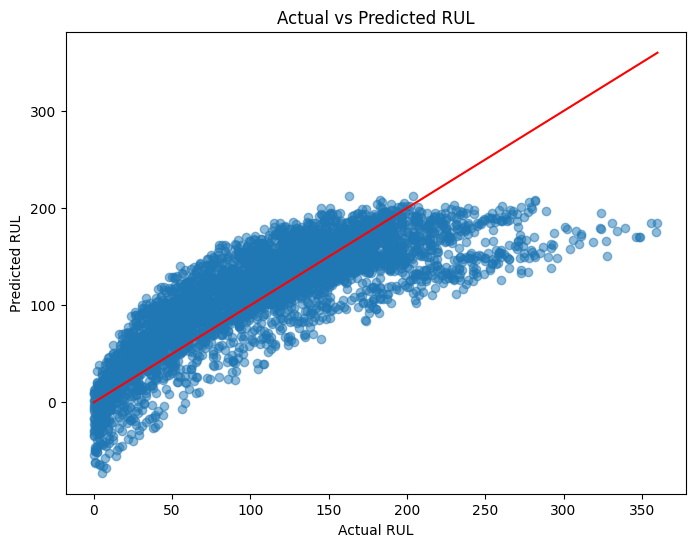

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

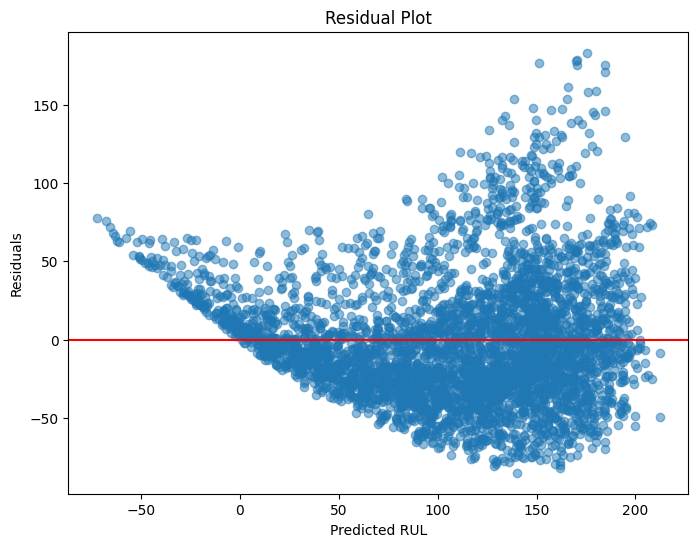

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [12]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,135,70.144657
1,2,32.511548
2,217,190.993343
3,0,-53.815488
4,178,104.683023
5,70,101.287046
6,87,134.516423
7,87,96.298124
8,73,122.868939
9,77,142.729766


## Conclusion

- A Linear Regression model was trained as the baseline for Remaining Useful Life prediction.
- Performance was evaluated using MAE, RMSE, and R² score.
- The baseline results will be used to compare the effectiveness of Decision Tree, Random Forest, and XGBoost models in the subsequent notebook.